# Classic Loop vs Iteration Log

Sou-Cheng Choi 

May 4, 2026

In high-dimensional integration, achieving high precision in solution estimate often requires solving the same problem across a wide range of tolerances ($\varepsilon$). Traditionally, this meant running the entire simulation multiple times, leading to prohibitive computational costs. This demo shows how using QMCPy's resume feature and internal solver logs can drastically reduce computational overhead while maintaining accuracy.

## Approach 1. Classic Loop
Use the same approach as in, for example, [MCQMC2022_Article_Figures.ipynb](../talk_paper_demos/MCQMC2022_Article_Figures/MCQMC2022_Article_Figures.ipynb), we will setup to create the two tolerance subplots:

1) Time vs tolerance and 
2) $n$ vs tolerance, each on log-log axes, with the Lattice series plus the $\mathcal{O}(\epsilon^{-1})$ reference trend.

This naive approach requires re-running the solver for every target tolerance. This method suffers from poor scaling, making it impractical for large-scale parameter sweeps.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter
from time import perf_counter
import qmcpy as qp

Approach 1:  elapsed=0.418793 s


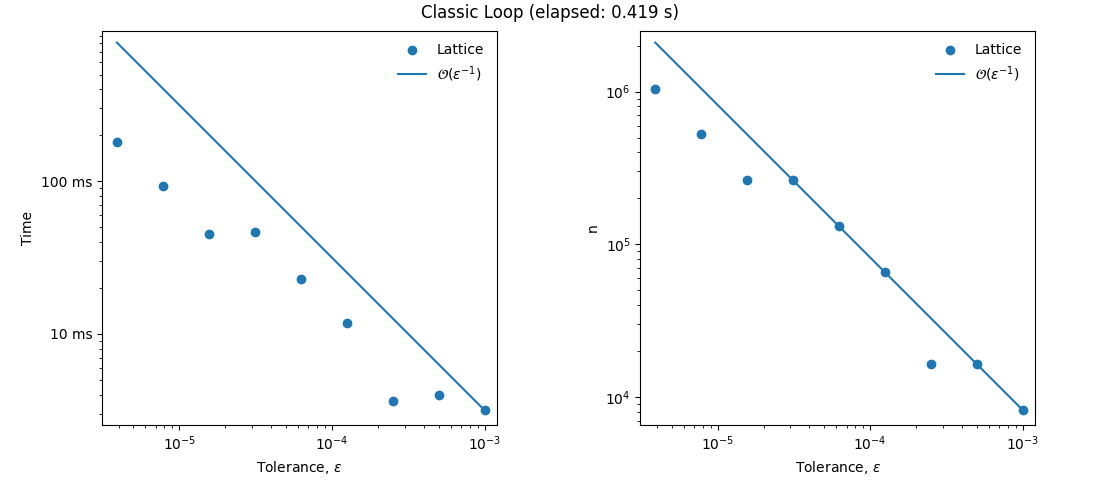

In [2]:
tol0, n_tol = 1e-3, 9
tol = np.array([tol0 / (2**i) for i in range(n_tol)])

def run_lattice_tolerance_curve(seed):
    integ = qp.Keister(qp.Gaussian(qp.Lattice(3, seed=seed)))
    times, ns = [], []
    for eps in tol:
        _, data = qp.CubQMCLatticeG(integ, abs_tol=float(eps)).integrate()
        times.append(float(data.time_integrate))
        ns.append(float(data.n_total))
    return np.asarray(times), np.asarray(ns)

def _time_fmt(y, _):
    """Format time in seconds, milliseconds, or microseconds depending on the magnitude."""
    if y >= 1:      return f"{y:g} s"
    if y >= 1e-3:   return f"{y * 1e3:g} ms"
    return f"{y * 1e6:g} us"

approach1_tic = perf_counter()
ld_time, ld_n = run_lattice_tolerance_curve(seed=7)
ref_time = (ld_time[0] * tol[0]) / tol
ref_n    = (ld_n[0]   * tol[0]) / tol
approach1_toc = perf_counter()
approach1_elapsed = approach1_toc - approach1_tic
print(f"Approach 1:  elapsed={approach1_elapsed:.6f} s")

fig1, ax1 = plt.subplots(1, 2, figsize=(11, 4.8), constrained_layout=True)
fig1.suptitle(f"Classic Loop (elapsed: {approach1_elapsed:.3f} s)")
for a, y1, ref, ylabel in zip(ax1,
        [ld_time, ld_n], [ref_time, ref_n], ["Time", "n"]):
    a.scatter(tol, y1,  color="tab:blue")
    a.plot(   tol, ref, color="tab:blue")
    a.set_ylabel(ylabel)
    a.set_xlim([tol.min() * 0.8, tol.max() * 1.2])
    a.set_ylim([np.r_[y1, ref].min() * 0.8, np.r_[y1, ref].max() * 1.2])
    a.set_xlabel("Tolerance, " + r"$\varepsilon$")
    a.set_xscale("log"); a.set_yscale("log")
    a.legend(["Lattice", r"$\mathcal{O}(\varepsilon^{-1})$"], frameon=False)
    a.set_box_aspect(1)

ax1[0].yaxis.set_major_formatter(FuncFormatter(_time_fmt))
plt.show();

## Approach 2. Iteration Log with Resume Approach

The solver is executed by first running it at the loosest tolerance and subsequently resuming the process at progressively tighter tolerances. Because each resumption starts from the previous state, the elapsed time accumulates naturally. This approach eliminates redundant computation, ensuring the solver only performs the additional work necessary to achieve increased precision.

Following any run (whether initial or resumed), users can retrieve the full raw iteration history and extract a vector of error surrogates indexed by tolerance $\varepsilon$. For Quasi-Monte Carlo (QMC) stopping criteria, this is typically `comb_bound_diff`; for Root Mean Square Error (RMSE)-based criteria, `rmse_estimate` or `rmse_tol` may be used. Note that the `get_iteration_log(...)` function returns a pandas DataFrame, meaning filtering and vector extraction require standard DataFrame operations. Furthermore, when performing a resumed run, it is essential to utilize the same solver instance.

The panels below plot elapsed time (or sample count $n$) versus tolerance $\varepsilon$. The solver executes sequentially, starting at the loosest tolerance and resuming at each tighter level. Consequently, every plotted point represents the cumulative time and sample count up to that specific stopping point. The Lattice (seed 7) series is overlaid with an $\mathcal{O}(\varepsilon^{-1})$ reference line on log-log axes for comparison.


In [3]:
def collect_log_rows_resume(method_name, seed):
    """Run at loosest tol, resume to tighter tols, and extract stop rows from iteration log."""
    integ = qp.Keister(qp.Gaussian(qp.Lattice(3, seed=seed)))
    sc = None
    data = None
    out_rows = []
    
    for eps in tol:  # loosest -> tightest 
        if sc is None:
            sc = qp.CubQMCLatticeG(integ, abs_tol=float(eps))
            _, data = sc.integrate()
        else:
            sc.set_tolerance(abs_tol=float(eps))  # update abs_tol 
            _, data = sc.integrate(resume=data)
        
        # Get the iteration log after THIS integration step
        log_df = sc.get_iteration_log(formatted=False)
        # The last row represents the current stopping point
        current_row = log_df.iloc[-1].copy()
        current_row['abs_tol'] = float(eps)
        out_rows.append(current_row)
    
    result_df = pd.DataFrame(out_rows)
    result_df.insert(0, "method", method_name)
    cols = ["method", "abs_tol", "elapsed_time", "n_total"]
    return result_df[cols].sort_values("abs_tol", ascending=False).reset_index(drop=True)

approach2_tic = perf_counter()
iter_log = collect_log_rows_resume("Lattice", seed=7)
approach2_toc = perf_counter()
approach2_elapsed = approach2_toc - approach2_tic
print(f"Approach 2: elapsed={approach2_elapsed:.6f} s")

iter_log.head(9)

Approach 2: elapsed=0.206153 s


,method,abs_tol,elapsed_time,n_total
0,Lattice,0.001000,0.003721,8192
1,Lattice,0.000500,0.005895,16384
2,Lattice,0.000250,0.005907,16384
3,Lattice,0.000125,0.015197,65536
4,Lattice,0.000063,0.028240,131072
5,Lattice,0.000031,0.054349,262144
6,Lattice,0.000016,0.054415,262144
7,Lattice,0.000008,0.103448,524288
8,Lattice,0.000004,0.191500,1048576


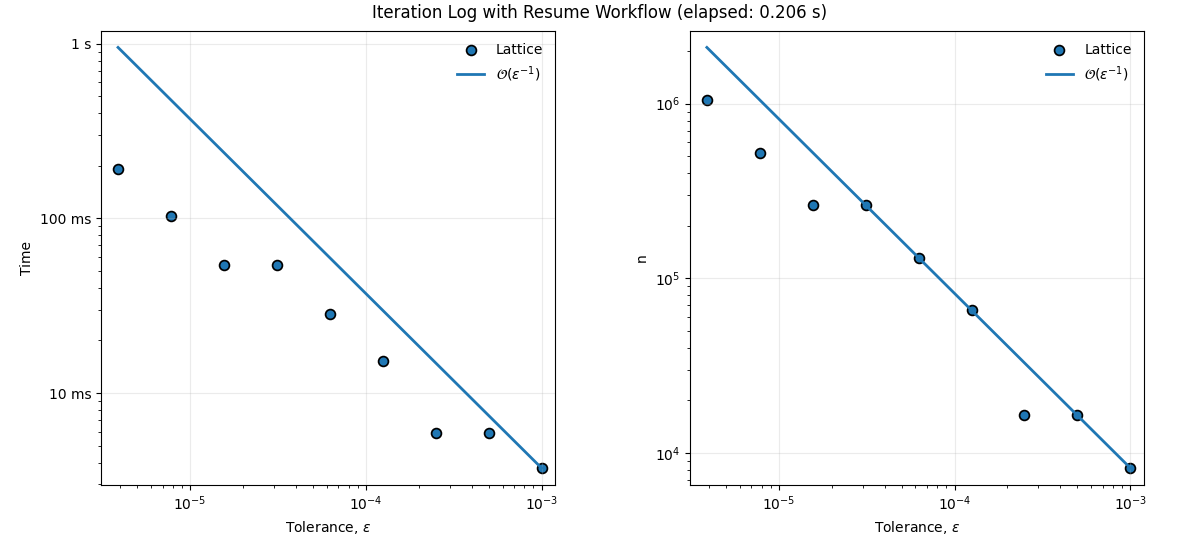

In [4]:
plot_df = iter_log.copy()
plot_df[["abs_tol", "elapsed_time", "n_total"]] = plot_df[
    ["abs_tol", "elapsed_time", "n_total"]
].apply(pd.to_numeric, errors="coerce")
plot_df = plot_df.sort_values(["method", "abs_tol"])

methods = [
    ("Lattice", "tab:blue", "o", 50),
]
xcol = "abs_tol"


def _positive_finite(arr):
    arr = np.asarray(arr, dtype=float)
    return arr[np.isfinite(arr) & (arr > 0)]


def draw_panel(ax_, ycol, ylabel):
    all_vals = []
    for method, color, marker, size in methods:
        d = plot_df[plot_df["method"] == method].sort_values(xcol)
        x = d[xcol].to_numpy(dtype=float)
        y = d[ycol].to_numpy(dtype=float)

        ax_.scatter(
            x, y, color=color, marker=marker, s=size, label=method,
            linewidths=2 if marker == "+" else 1.25,
            edgecolors="black" if marker == "o" else None
        )
        all_vals.append(y)

        if method == "Lattice":
            ref = y[-1] * x[-1] / x
            ax_.plot(x, ref, color=color, linewidth=2, label=r"$\mathcal{O}(\varepsilon^{-1})$")
            all_vals.append(ref)

    vals = _positive_finite(np.concatenate(all_vals))
    xvals = _positive_finite(plot_df[xcol].to_numpy(dtype=float))

    ax_.set_xscale("log")
    ax_.set_yscale("log")
    ax_.set_xlim([xvals.min() * 0.8, xvals.max() * 1.2])
    ax_.set_ylim([vals.min() * 0.8, vals.max() * 1.25])
    ax_.set_xlabel("Tolerance, " + r"$\varepsilon$")
    ax_.set_ylabel(ylabel)
    ax_.grid(True, which="major", alpha=0.25)
    ax_.legend(frameon=False)
    ax_.set_box_aspect(1)

fig2, ax = plt.subplots(1, 2, figsize=(12, 5.4), constrained_layout=True)
fig2.suptitle(f"Iteration Log with Resume Workflow (elapsed: {approach2_elapsed:.3f} s)")
draw_panel(ax[0], "elapsed_time", "Time")
draw_panel(ax[1], "n_total", "n")
ax[0].yaxis.set_major_formatter(FuncFormatter(_time_fmt))
plt.show();


Below, we repeat Approach 1 figure for easy comparison. While the suplots looks similar, total run time of Approach 2 is substantially less.

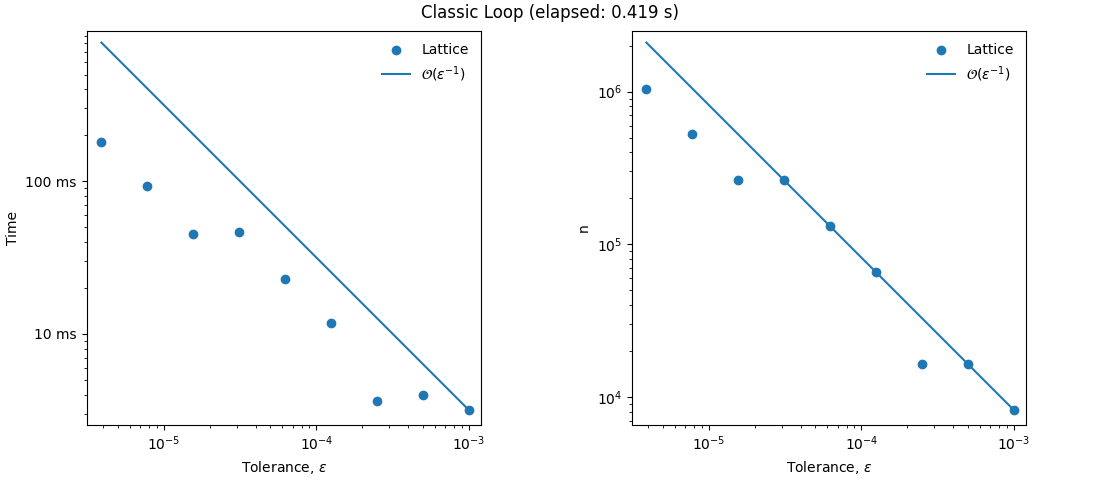

In [5]:

display(fig1)


Next, we benchmark the two workflows in a more systematic way than a single `perf_counter()` measurement. It defines one function that runs the classic loop once and another that runs the iteration-log-with-resume workflow once, then uses Python's `timeit.repeat(...)` to execute each approach several times.

The resulting table reports the average runtime, standard deviation, minimum, and maximum across repeated runs. This gives a more stable comparison of the production cost of the two approaches than relying on a single observed elapsed time.

In [ ]:
import timeit

REPEAT = 10

def run_approach1_once():
    ld_time_bench, ld_n_bench = run_lattice_tolerance_curve(seed=7)
    return float(ld_time_bench.sum()), float(ld_n_bench[-1])

def run_approach2_once():
    iter_log_bench = collect_log_rows_resume("Lattice", seed=7)
    return (float(iter_log_bench["elapsed_time"].iloc[-1]),
            float(iter_log_bench["n_total"].iloc[-1]))

def benchmark_callable(func, repeat=REPEAT):
    samples = np.asarray(timeit.repeat(func, number=1, repeat=repeat), dtype=float)
    return pd.Series({"average": float(samples.mean()),
                        "stdev": float(samples.std(ddof=1)) if len(samples) > 1 else 0.0,
                        "min": float(samples.min()),
                        "max": float(samples.max()),
                        "repeat": int(repeat),
                        })

benchmark_results = pd.DataFrame(
                {"Classic Loop":          benchmark_callable(run_approach1_once),
                "Iteration Log + Resume": benchmark_callable(run_approach2_once),}).T
display(benchmark_results)

,average,stdev,min,max,repeat
Classic Loop,0.451284,0.026860,0.422231,0.499791,10.0
Iteration Log + Resume,0.207784,0.005101,0.201278,0.219131,10.0


# Conclusions

The Iteration Log with resume workflow in QMCPy represents a critical methodological advancement for computational simulations requiring multi-tolerance analysis. It transforms a computationally prohibitive task into an efficient process by leveraging internal solver data, allowing researchers to explore parameter space with unprecedented speed.